# 04 Classification and regression evaluation

Baselines versus selected models on the chronological test period: precision-recall, calibration, thresholds, error analysis and uncertainty.

> Data: Online Retail II, UCI Machine Learning Repository (Chen, 2019, CC BY 4.0). Historical transactions from 1 Dec 2009 to 9 Dec 2011. This notebook reads the PostgreSQL tables produced by `gci import-data`, `gci build-analytics`, `gci build-features` and `gci train`; reusable logic lives in the `gci` package, not here.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import text
from gci.db.session import session_scope
from gci.api.sqlfiles import load_sql
sns.set_theme(style="whitegrid", palette=["#1D4ED8", "#94A3B8", "#0F1F3D", "#B45309"])
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
GBP = lambda v: f"£{v:,.0f}"

def q(sql, **params):
    with session_scope() as s:
        return pd.read_sql(text(sql) if isinstance(sql, str) else sql, s.connection(), params=params)

def findings(items):
    display(Markdown("\n".join(f"{i+1}. {t}" for i, t in enumerate(items))))

## 1. Active model runs

All numbers below are read from the stored model runs (MLflow-tracked) and recomputed on the held-out test period with the *evaluated* pipelines (fitted on the training period, tuned on validation).

In [2]:
from gci.features.snapshots import load_snapshots
from gci.ml.common import prepare_X, split_frames
from gci.ml.tracking import active_run, load_artifact
from gci.ml.metrics import calibration_table, precision_at_k_by_cutoff, grouped_bootstrap_ci, ap_statistic
from sklearn.metrics import precision_recall_curve, average_precision_score, brier_score_loss
with session_scope() as s:
    clf_run, reg_run = active_run(s, "classification"), active_run(s, "regression"); snaps = load_snapshots(s)
parts = split_frames(snaps); train, val, test = parts["train"], parts["validation"], parts["test"]
for r in (clf_run, reg_run):
    print(f"{r.model_type}: {r.model_version} | {r.algorithm} | train {r.train_start}..{r.train_end} (n={r.n_train:,}) | validation {r.validation_start}..{r.validation_end} (n={r.n_validation:,}) | test {r.test_start}..{r.test_end} (n={r.n_test:,}) | data {r.data_version[:12]}")
print("Purged snapshots:", int((snaps.dataset_split == "purged").sum()), "| base rate train/val/test:", round(train.label_purchased.mean(),3), round(val.label_purchased.mean(),3), round(test.label_purchased.mean(),3))

classification: classification-20260921-200300 | HistGradientBoostingClassifier | train 2010-03-01..2011-05-01 (n=52,720) | validation 2011-06-01..2011-08-01 (n=15,041) | test 2011-09-01..2011-11-01 (n=16,269) | data bcbe73b35f5b
regression: regression-20260921-200501 | HistGradientBoostingRegressor on log1p(target) | train 2010-03-01..2011-05-01 (n=52,720) | validation 2011-06-01..2011-08-01 (n=15,041) | test 2011-09-01..2011-11-01 (n=16,269) | data bcbe73b35f5b
Purged snapshots: 0 | base rate train/val/test: 0.227 0.167 0.224


## 2. Classification: baseline vs candidates

,model,selected,baseline,val AP,test AP,test ROC-AUC,test P@100,test Brier
0,dummy_prior,False,True,0.17,0.22,0.50,0.27,0.17
1,logistic_regression,False,False,0.54,0.56,0.78,0.90,0.14
2,hist_gradient_boosting,True,False,0.56,0.58,0.79,0.90,0.14


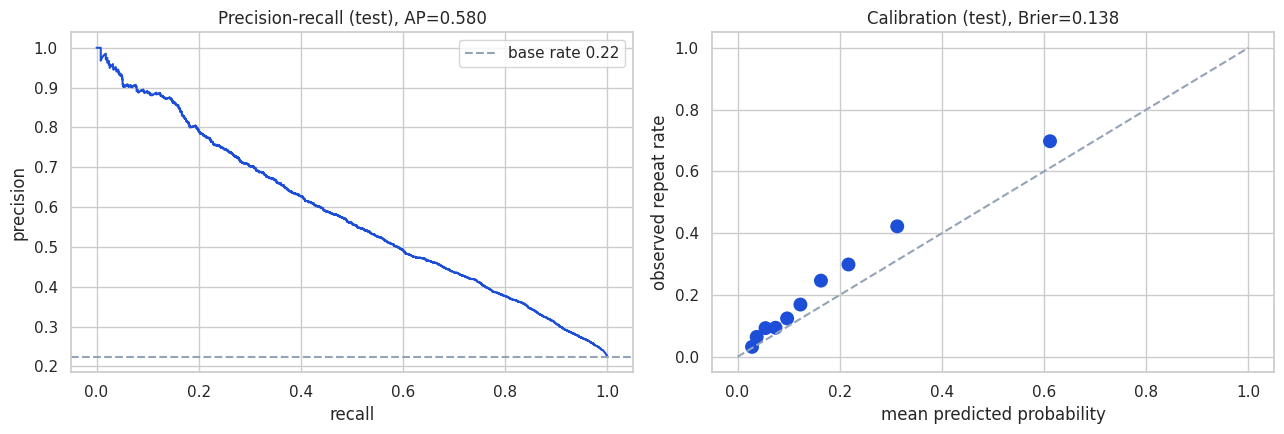

,bin_lower,bin_upper,mean_predicted,observed_rate,count
0,0.03,0.03,0.03,0.03,1621
1,0.03,0.04,0.04,0.06,1633
2,0.04,0.07,0.05,0.09,1627
3,0.07,0.09,0.07,0.09,1627
4,0.09,0.11,0.10,0.12,1626
5,0.11,0.14,0.12,0.17,1627
6,0.14,0.19,0.16,0.25,1627
7,0.19,0.25,0.22,0.30,1627
8,0.25,0.40,0.31,0.42,1627
9,0.40,0.95,0.61,0.70,1627


In [3]:
comp = pd.DataFrame([{"model": c["model_name"], "selected": c["is_selected"], "baseline": c["is_baseline"],
                      "val AP": c["validation_metrics"]["average_precision"], "test AP": c["test_metrics"]["average_precision"],
                      "test ROC-AUC": c["test_metrics"]["roc_auc"], "test P@100": c["test_metrics"]["precision_at_100"], "test Brier": c["test_metrics"]["brier_score"]} for c in clf_run.comparison]); display(comp)
clf = load_artifact(clf_run.artifact_path, "evaluated_model.joblib")
prob = clf.predict_proba(prepare_X(test))[:, 1]; y = test.label_purchased.to_numpy()
p, r, _ = precision_recall_curve(y, prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(r, p, color="#1D4ED8"); axes[0].axhline(y.mean(), ls="--", color="#94A3B8", label=f"base rate {y.mean():.2f}"); axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_title(f"Precision-recall (test), AP={average_precision_score(y, prob):.3f}"); axes[0].legend()
cal = pd.DataFrame(calibration_table(y, prob)); axes[1].plot([0,1],[0,1], ls="--", color="#94A3B8"); axes[1].scatter(cal.mean_predicted, cal.observed_rate, s=cal["count"]/20, color="#1D4ED8"); axes[1].set_xlabel("mean predicted probability"); axes[1].set_ylabel("observed repeat rate"); axes[1].set_title(f"Calibration (test), Brier={brier_score_loss(y, prob):.3f}")
plt.tight_layout(); plt.show(); display(cal)

## 3. Operating threshold, top-100 precision and error analysis

In [4]:
m = clf_run.metrics; print("Threshold", m["threshold"], "chosen on validation:", clf_run.params["threshold_rule"])
display(pd.DataFrame(m["thresholds"]))
pak = precision_at_k_by_cutoff(test.assign(prob=prob), "prob", "label_purchased", k=100); display(pd.DataFrame(pak["per_cutoff"]))
print(f"Mean precision@100 {pak['mean_precision_at_k']:.3f} vs base rate {pak['mean_base_rate']:.3f} -> lift {pak['lift_at_k']:.2f}x; smallest ranking {pak['min_ranking_size']}")
display(pd.DataFrame(m["error_analysis"]))
lo, hi = grouped_bootstrap_ci(test.assign(prob=prob), ap_statistic("prob", "label_purchased"), n_boot=300)
print(f"Customer-grouped bootstrap 95% CI for test AP: {lo:.3f} to {hi:.3f}")

Threshold 0.25 chosen on validation: maximise F1 on validation; full trade-off table stored


,recall,precision,threshold,flagged_count,flagged_share
0,0.84,0.35,0.10,8738,0.54
1,0.60,0.49,0.20,4495,0.28
2,0.42,0.61,0.30,2523,0.16
3,0.31,0.69,0.40,1636,0.10
4,0.23,0.75,0.50,1134,0.07
5,0.17,0.83,0.60,731,0.04
6,0.11,0.88,0.70,465,0.03
7,0.06,0.90,0.80,252,0.02


,cutoff_date,ranking_size,eligible_customers,precision_at_k,base_rate
0,2011-09-01,100,5224,0.90,0.21
1,2011-10-01,100,5412,0.84,0.20
2,2011-11-01,100,5633,0.97,0.26


Mean precision@100 0.903 vs base rate 0.223 -> lift 4.04x; smallest ranking 100


,count,bucket,recall,precision,mean_actual,mean_predicted
0,3573,Last purchase 0-30 days ago,0.75,0.60,0.42,0.36
1,2966,31-90 days,0.57,0.51,0.34,0.25
2,2360,91-180 days,0.24,0.46,0.21,0.15
3,4160,181-365 days,0.00,NaN,0.11,0.08
4,3210,Over 365 days,0.00,NaN,0.05,0.03


Customer-grouped bootstrap 95% CI for test AP: 0.560 to 0.599


## 4. Regression: predicted 30-day purchase spending

,model,selected,baseline,val MAE,test MAE,test RMSE,mean pred,mean actual
0,baseline_zero,False,True,110.36,170.68,"1,192.90",0.00,170.68
1,baseline_recent_run_rate,False,True,122.49,165.58,876.33,133.75,170.68
2,hgb_squared_error,False,False,130.15,172.72,924.51,112.87,170.68
3,hgb_log_target,True,False,97.45,155.58,"1,086.87",22.96,170.68
4,hgb_absolute_error,False,False,110.36,170.68,"1,192.90",0.00,170.68


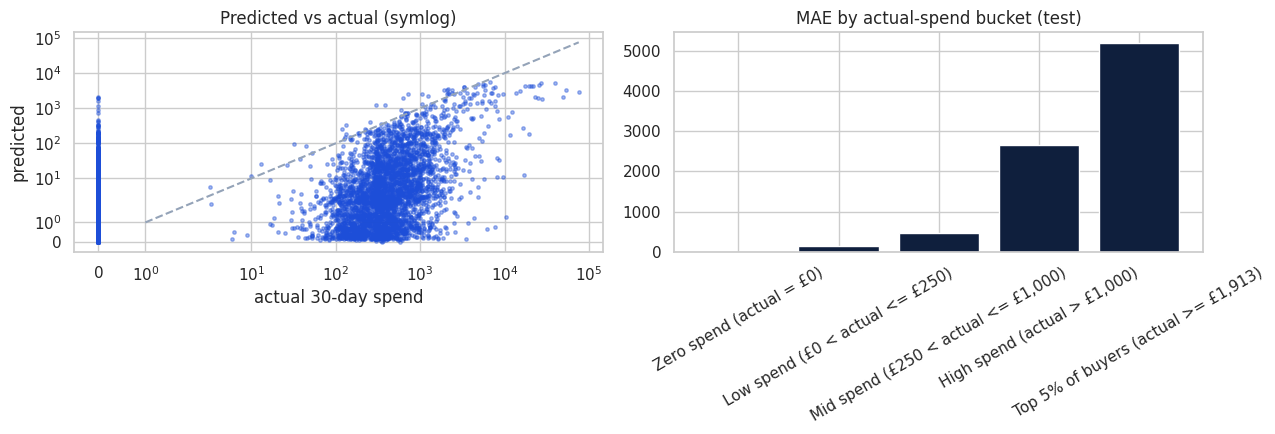

,mae,rmse,count,bucket,mean_actual,mean_predicted
0,3.72,39.34,12622,Zero spend (actual = £0),0.00,3.72
1,148.17,159.19,1006,Low spend (£0 < actual <= £250),155.71,8.75
2,463.02,503.54,2133,"Mid spend (£250 < actual <= £1,000)",491.35,33.53
3,"2,652.41","6,056.27",508,"High spend (actual > £1,000)","3,094.74",484.74
4,"5,198.65","9,949.39",183,"Top 5% of buyers (actual >= £1,913)","6,229.11","1,119.33"


In [5]:
rcomp = pd.DataFrame([{"model": c["model_name"], "selected": c["is_selected"], "baseline": c["is_baseline"], "val MAE": c["validation_metrics"]["mae"],
                       "test MAE": c["test_metrics"]["mae"], "test RMSE": c["test_metrics"]["rmse"], "mean pred": c["test_metrics"]["mean_predicted"], "mean actual": c["test_metrics"]["mean_actual"]} for c in reg_run.comparison]); display(rcomp)
reg = load_artifact(reg_run.artifact_path, "evaluated_model.joblib"); pred = np.clip(reg.predict(prepare_X(test)), 0, None); ys = test.label_spend.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(ys, pred, s=6, alpha=.4, color="#1D4ED8"); axes[0].plot([1, ys.max()], [1, ys.max()], ls="--", color="#94A3B8"); axes[0].set_xscale("symlog"); axes[0].set_yscale("symlog"); axes[0].set_xlabel("actual 30-day spend"); axes[0].set_ylabel("predicted"); axes[0].set_title("Predicted vs actual (symlog)")
err = pd.DataFrame(reg_run.metrics["error_analysis"]); axes[1].bar(err.bucket, err.mae, color="#0F1F3D"); axes[1].set_title("MAE by actual-spend bucket (test)"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); display(err)

## 5. Findings and limitations

Metrics describe how well historical behaviour predicts historical outcomes. They do not show that contacting a high-probability customer changes anything; that needs a controlled test.

In [6]:
sel = comp[comp.selected].iloc[0]; base = comp[comp.baseline].iloc[0]; rsel = rcomp[rcomp.selected].iloc[0]; rbase = rcomp[rcomp.baseline].sort_values("test MAE").iloc[0]
findings([
 f"The selected classifier ({sel.model}) reaches test average precision {sel['test AP']:.2f} against a base rate of {base['test AP']:.2f}; ranking the top 100 customers per cutoff gives precision {pak['mean_precision_at_k']:.2f} ({pak['lift_at_k']:.1f}x lift).",
 f"Calibration is close to the diagonal (Brier {m['test']['brier_score']:.3f}); the largest deviation is in the highest-probability bin, so probabilities above ~0.8 should be read as 'very likely' rather than exact.",
 f"At the validation-chosen threshold {m['threshold']} the model flags {m['test']['flagged_share']:.0%} of customers with precision {m['test']['precision']:.2f} and recall {m['test']['recall']:.2f}; the threshold table shows the coverage/precision trade-off for other operating points.",
 f"For spending, {rsel.model} has test MAE {GBP(rsel['test MAE'])} vs {GBP(rbase['test MAE'])} for the best baseline ({rbase.model}); RMSE is dominated by a few very large buyers and the model under-predicts the mean ({GBP(rsel['mean pred'])} vs {GBP(rsel['mean actual'])}), so predictions rank customers but must not be summed as a forecast.",
 "Limitations: customers appear in several monthly snapshots (not independent), the test period is the pre-Christmas peak, only identified customers are scored, and every score refers to 10 December 2011.",
])
print(); print("Stored limitations:"); [print(" -", l) for l in clf_run.limitations]

1. The selected classifier (hist_gradient_boosting) reaches test average precision 0.58 against a base rate of 0.22; ranking the top 100 customers per cutoff gives precision 0.90 (4.0x lift).
2. Calibration is close to the diagonal (Brier 0.138); the largest deviation is in the highest-probability bin, so probabilities above ~0.8 should be read as 'very likely' rather than exact.
3. At the validation-chosen threshold 0.25 the model flags 20% of customers with precision 0.56 and recall 0.50; the threshold table shows the coverage/precision trade-off for other operating points.
4. For spending, hgb_log_target has test MAE £156 vs £166 for the best baseline (baseline_recent_run_rate); RMSE is dominated by a few very large buyers and the model under-predicts the mean (£23 vs £171), so predictions rank customers but must not be summed as a forecast.
5. Limitations: customers appear in several monthly snapshots (not independent), the test period is the pre-Christmas peak, only identified customers are scored, and every score refers to 10 December 2011.


Stored limitations:
 - Reported test metrics come from the model fitted on the training period; the scoring model uses the same hyper-parameters refitted on all labelled snapshots so it sees the most recent behaviour.
 - The test period (autumn 2011) is the pre-Christmas peak; precision and lift may differ in quieter months.
 - Precision@100 is averaged over test cutoffs; the smallest ranking scored 100 customers.
 - Snapshots are taken monthly, so most customers appear several times in the training data; observations are not independent. Confidence intervals resample whole customers to reflect this, but they remain approximate.
 - The data ends on 9 December 2011. Scores are computed at the latest usable historical cutoff (10 December 2011) and describe that point in time, not current activity.
 - Only identified customers (with a customer ID) are modelled; anonymous transactions are reported in aggregates but never scored.
 - Feature importance or model coefficients describe associa

[None, None, None, None, None, None, None]